In [ ]:
!pip install qiskit matplotlib


In [ ]:
!pip install qiskit-aer

Quantum Circuit:
        ┌───┐ ░ ┌─┐      
   q_0: ┤ H ├─░─┤M├──────
        ├───┤ ░ └╥┘┌─┐   
   q_1: ┤ H ├─░──╫─┤M├───
        ├───┤ ░  ║ └╥┘┌─┐
   q_2: ┤ H ├─░──╫──╫─┤M├
        └───┘ ░  ║  ║ └╥┘
meas: 3/═════════╩══╩══╩═
                 0  1  2 
Quantum Random Number Distribution:
{'001': 107, '011': 134, '111': 135, '101': 120, '100': 128, '010': 141, '000': 109, '110': 126}


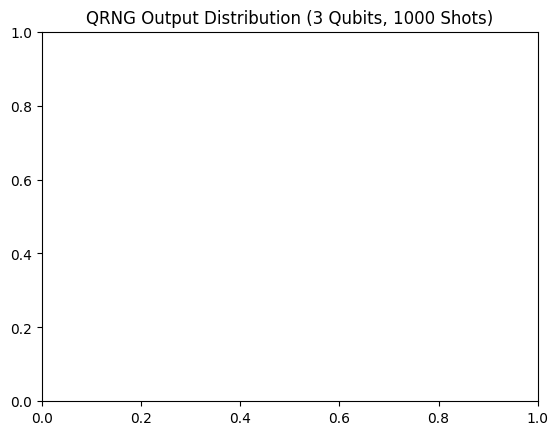

In [ ]:
# Quantum Random Number Generator using Qiskit (Updated Version)

from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


def create_qrng_circuit(num_qubits: int = 3) -> QuantumCircuit:
    qc = QuantumCircuit(num_qubits)

    # Create superposition
    for qubit in range(num_qubits):
        qc.h(qubit)

    # Measure all qubits
    qc.measure_all()

    return qc


def run_simulation(qc: QuantumCircuit, shots: int = 1000):
    simulator = Aer.get_backend('aer_simulator')

    job = simulator.run(qc, shots=shots)
    result = job.result()
    counts = result.get_counts()

    return counts


def display_results(counts: dict):
    print("Quantum Random Number Distribution:")
    print(counts)

    plot_histogram(counts)
    plt.title("QRNG Output Distribution (3 Qubits, 1000 Shots)")
    plt.show()


def main():
    qrng_circuit = create_qrng_circuit(3)

    print("Quantum Circuit:")
    print(qrng_circuit)

    counts = run_simulation(qrng_circuit, 1000)

    display_results(counts)


if __name__ == "__main__":
    main()